In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create Grid Environment
# -------------------------------------------------

class GridWorld(gym.Env):

    def __init__(self):
        super().__init__()

        # 4 x 4 grid
        self.rows = 4
        self.cols = 4

        # Start and Goal
        self.start = (0, 0)
        self.goal = (3, 3)

        # Obstacles
        self.obstacles = {
            (1, 1),
            (1, 2),
            (2, 1)
        }

        # 4 actions:
        # 0 = Left
        # 1 = Down
        # 2 = Right
        # 3 = Up

        self.action_space = gym.spaces.Discrete(4)
        self.observation_space = gym.spaces.Discrete(16)

        self.state = self.start

    def state_to_number(self, state):
        return state[0] * self.cols + state[1]

    def number_to_state(self, state):
        return (state // self.cols, state % self.cols)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.state = self.start

        return self.state_to_number(self.state), {}

    def step(self, action):

        row, col = self.state

        # Movement
        if action == 0:       # Left
            new_row, new_col = row, col - 1

        elif action == 1:     # Down
            new_row, new_col = row + 1, col

        elif action == 2:     # Right
            new_row, new_col = row, col + 1

        else:                 # Up
            new_row, new_col = row - 1, col

        # Check boundaries
        if (
            new_row < 0 or
            new_row >= self.rows or
            new_col < 0 or
            new_col >= self.cols
        ):
            new_row, new_col = row, col
            reward = -2

        # Check obstacles
        elif (new_row, new_col) in self.obstacles:
            new_row, new_col = row, col
            reward = -2

        else:
            reward = -1

        self.state = (new_row, new_col)

        # Goal
        terminated = self.state == self.goal

        if terminated:
            reward = 10

        truncated = False

        return (
            self.state_to_number(self.state),
            reward,
            terminated,
            truncated,
            {}
        )


env = GridWorld()



In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.8
discount_factor = 0.95

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 5000

In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((
    env.observation_space.n,
    env.action_space.n
))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    return np.argmax(Q[state])



In [6]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0
    done = False

    while not done:

        # Choose action
        action = choose_action(state)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Q-Learning update
        best_next_value = np.max(Q[next_state])

        Q[state, action] = Q[state, action] + learning_rate * (
            reward
            + discount_factor * best_next_value
            - Q[state, action]
        )

        state = next_state

        total_reward += reward

    episode_rewards.append(total_reward)

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )








In [8]:
# -------------------------------------------------
# Calculate Value Function and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)

In [9]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [10]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[ 1.053  3.213  3.213  1.053]
 [ 2.053  2.213  4.435  2.213]
 [ 3.213  3.435  5.721  3.435]
 [ 4.435  7.075  4.721  4.721]
 [ 2.213  4.435  2.213  2.053]
 [ 0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 6.075  8.5    6.075  5.721]
 [ 3.435  5.721  3.435  3.213]
 [ 0.     0.     0.     0.   ]
 [ 6.075  8.5    8.5    6.075]
 [ 7.075 10.     7.5    7.075]
 [ 4.721  4.721  7.075  4.435]
 [ 5.721  6.075  8.5    6.075]
 [ 7.075  7.5   10.     7.075]
 [ 0.     0.     0.     0.   ]]

Estimated State-Value Function:
[[ 3.213  4.435  5.721  7.075]
 [ 4.435  0.     0.     8.5  ]
 [ 5.721  0.     8.5   10.   ]
 [ 7.075  8.5   10.     0.   ]]

Learned Policy:
[['D' 'R' 'R' 'D']
 ['D' 'L' 'L' 'D']
 ['D' 'L' 'R' 'D']
 ['R' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 4.92


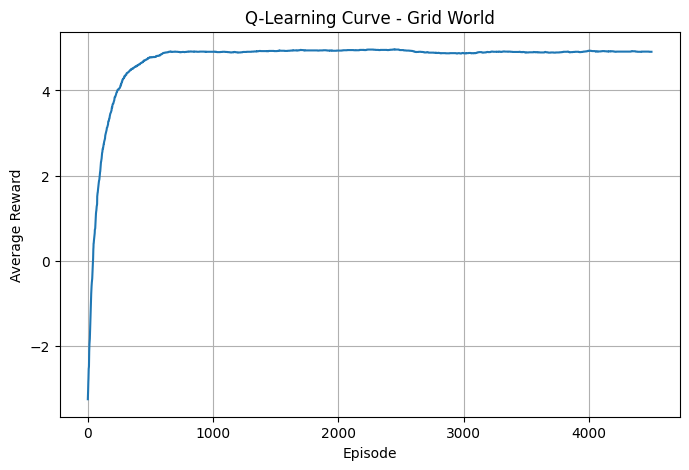

In [11]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - Grid World")
plt.grid(True)
plt.show()

env.close()